# Audit of Fake News Detection Model
### By: Jack Hariri and Noga Gottlieb
### New York University (Spring 2026)
### Auditing https://huggingface.co/hamzab/roberta-fake-news-classification 


In [1]:
#importing the necessary libraries and loading the pre-trained model

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd
import torch

tokenizer = AutoTokenizer.from_pretrained("hamzab/roberta-fake-news-classification")

model = AutoModelForSequenceClassification.from_pretrained("hamzab/roberta-fake-news-classification")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: hamzab/roberta-fake-news-classification
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [2]:
#function to predict if the news is fake or real
def predict_fake(title,text):
    input_str = "<title>" + title + "<content>" +  text + "<end>"
    input_ids = tokenizer(text, padding=True, truncation=True, return_tensors="pt")
    device =  'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    with torch.no_grad():
        output = model(input_ids["input_ids"].to(device), attention_mask=input_ids["attention_mask"].to(device))
    return dict(zip(["Fake","Real"], [x.item() for x in list(torch.nn.Softmax()(output.logits)[0])] ))
    
print(predict_fake('This is a headline','This is real news, trust me'))

{'Fake': 0.999137282371521, 'Real': 0.0008626455091871321}


/opt/anaconda3/lib/python3.13/site-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [3]:
#loading the datasets
fake_news = pd.read_csv(
    "Fake.csv",
    engine="python",      
    quotechar='"',
    escapechar='\\',     
    on_bad_lines="skip"   
)
real_news = pd.read_csv(
    "True.csv",
    engine="python",   
    quotechar='"',
    escapechar='\\',      #
    on_bad_lines="skip"   
)

In [4]:
#creating a dictionary to store the results of the predictions
fake_news_results = {'fake': [],
                     'real': []}

fake_news_test = fake_news.head(10)
display(fake_news_test)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017"
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017"
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017"
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017"
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017"


In [5]:
#predicting if the news is fake or real and storing the results in the dictionary
for _, article in fake_news_test.iterrows():
    result = predict_fake(article['title'], article['text'])
    fake_news_results['fake'].append(result['Fake'])
    fake_news_results['real'].append(result['Real'])
    


print (sum(fake_news_results['fake'])/len(fake_news_results['fake']))

/opt/anaconda3/lib/python3.13/site-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


0.7174275479730567


In [6]:
#loading the test dataset columns
columns = [
    "id",
    "label",
    "statement",
    "subjects",
    "speaker",
    "job_title",
    "state_info",
    "party_affiliation",
    "barely_true_count",
    "false_count",
    "half_true_count",
    "mostly_true_count",
    "pants_on_fire_count",
    "context"
]

In [7]:
#loading the test dataset
newstotest = pd.read_csv(
    "test.tsv",
    sep="\t",
    header=None,     
    names=columns   
)

fake_news_test = newstotest.head(10)
display(fake_news_test)

,id,label,statement,subjects,speaker,job_title,state_info,party_affiliation,barely_true_count,false_count,half_true_count,mostly_true_count,pants_on_fire_count,context
0,11972.json,true,Building a wall on the U.S.-Mexico border will...,immigration,rick-perry,Governor,Texas,republican,30,30,42,23,18,Radio interview
1,11685.json,false,Wisconsin is on pace to double the number of l...,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference
2,11096.json,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.
3,5209.json,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",rob-cornilles,consultant,Oregon,republican,1,1,3,1,1,a radio show
4,9524.json,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",state-democratic-party-wisconsin,NaN,Wisconsin,democrat,5,7,2,2,7,a web video
5,5962.json,true,Over the past five years the federal governmen...,"federal-budget,pensions,retirement",brendan-doherty,NaN,Rhode Island,republican,1,2,1,1,0,a campaign website
6,7070.json,true,Says that Tennessee law requires that schools ...,"county-budget,county-government,education,taxes",stand-children-tennessee,Child and education advocacy organization.,Tennessee,none,0,0,0,0,0,in a post on Facebook.
7,1046.json,barely-true,"Says Vice President Joe Biden ""admits that the...","economy,stimulus",john-boehner,Speaker of the House of Representatives,Ohio,republican,13,22,11,4,2,a press release.
8,12849.json,true,Donald Trump is against marriage equality. He ...,"gays-and-lesbians,marriage",sean-patrick-maloney,Congressman for NY-18,New York,democrat,0,0,0,0,0,a speech at the Democratic National Convention
9,13270.json,barely-true,We know that more than half of Hillary Clinton...,foreign-policy,mike-pence,Governor,Indiana,republican,8,10,12,5,0,"comments on ""Meet the Press"""


In [8]:
for _, article in fake_news_test.iterrows():
    result = predict_fake(article['id'], article['statement'])
    fake_news_results['fake'].append(result['Fake'])
    fake_news_results['real'].append(result['Real'])
    print(f"Statement: {article['statement']}, Prediction: {result['Real']}, True Value: {article['label']}")
    
print (sum(fake_news_results['fake'])/len(fake_news_results['fake']))

Statement: Building a wall on the U.S.-Mexico border will take literally years., Prediction: 0.9999104738235474, True Value: true
Statement: Wisconsin is on pace to double the number of layoffs this year., Prediction: 0.9999163150787354, True Value: false
Statement: Says John McCain has done nothing to help the vets., Prediction: 0.0008580216090194881, True Value: false
Statement: Suzanne Bonamici supports a plan that will cut choice for Medicare Advantage seniors., Prediction: 0.9996377229690552, True Value: half-true


/opt/anaconda3/lib/python3.13/site-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Statement: When asked by a reporter whether hes at the center of a criminal scheme to violate campaign laws, Gov. Scott Walker nodded yes., Prediction: 0.520537257194519, True Value: pants-fire
Statement: Over the past five years the federal government has paid out $601 million in retirement and disability benefits to deceased former federal employees., Prediction: 0.9998948574066162, True Value: true
Statement: Says that Tennessee law requires that schools receive half of proceeds -- $31 million per year -- from a half-cent increase in the Shelby County sales tax., Prediction: 0.9995959401130676, True Value: true
Statement: Says Vice President Joe Biden "admits that the American people are being scammed" with the economic stimulus package., Prediction: 0.0002514163206797093, True Value: barely-true
Statement: Donald Trump is against marriage equality. He wants to go back., Prediction: 0.00033704019733704627, True Value: true
Statement: We know that more than half of Hillary Clintons m

In [9]:
reuters_count = real_news['text'].str.contains('Reuters').sum()

print(f"Number of articles containing 'Reuters': {reuters_count}")

Number of articles containing 'Reuters': 21378


In [10]:
label_mapping = {
    'true': 1,
    'mostly-true': None, 
    'false': 0,
    'pants-fire': 0,
    'barely-true': None,
    'half-true': None
}

newstotest['true_label'] = newstotest['label'].map(label_mapping)
clear_news_to_test = newstotest.dropna(subset=['true_label'])

# Convert to integer so metrics work correctly
clear_news_to_test['true_label'] = clear_news_to_test['true_label'].astype(int)


/var/folders/48/31qzysgd41q_sp2lykmzglsc0000gn/T/ipykernel_70211/783476531.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clear_news_to_test['true_label'] = clear_news_to_test['true_label'].astype(int)


In [11]:
preds = []
pred_labels = []
for index, article in clear_news_to_test.iterrows():
    result = predict_fake(article['id'], article['statement'])
    real_score = result['Real']
    label = 1 if real_score > 0.5 else 0
    preds.append(real_score)
    pred_labels.append(label)

clear_news_to_test['pred'] = preds
clear_news_to_test['pred_label'] = pred_labels


/opt/anaconda3/lib/python3.13/site-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/var/folders/48/31qzysgd41q_sp2lykmzglsc0000gn/T/ipykernel_70211/2736583728.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clear_news_to_test['pred'] = preds
/var/folders/48/31qzysgd41q_sp2lykmzglsc0000gn/T/ipykernel_70211/2736583728.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-

In [12]:
clear_news_to_test.head(10)

,id,label,statement,subjects,speaker,job_title,state_info,party_affiliation,barely_true_count,false_count,half_true_count,mostly_true_count,pants_on_fire_count,context,true_label,pred,pred_label
0,11972.json,true,Building a wall on the U.S.-Mexico border will...,immigration,rick-perry,Governor,Texas,republican,30,30,42,23,18,Radio interview,1,0.999910,1
1,11685.json,false,Wisconsin is on pace to double the number of l...,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference,0,0.999916,1
2,11096.json,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.,0,0.000858,0
4,9524.json,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",state-democratic-party-wisconsin,NaN,Wisconsin,democrat,5,7,2,2,7,a web video,0,0.520537,1
5,5962.json,true,Over the past five years the federal governmen...,"federal-budget,pensions,retirement",brendan-doherty,NaN,Rhode Island,republican,1,2,1,1,0,a campaign website,1,0.999895,1
6,7070.json,true,Says that Tennessee law requires that schools ...,"county-budget,county-government,education,taxes",stand-children-tennessee,Child and education advocacy organization.,Tennessee,none,0,0,0,0,0,in a post on Facebook.,1,0.999596,1
8,12849.json,true,Donald Trump is against marriage equality. He ...,"gays-and-lesbians,marriage",sean-patrick-maloney,Congressman for NY-18,New York,democrat,0,0,0,0,0,a speech at the Democratic National Convention,1,0.000337,0
12,11269.json,pants-fire,Denali is the Kenyan word for black power.,environment,viral-image,NaN,NaN,none,5,5,0,3,15,an image shared on Facebook,0,0.999209,1
13,11200.json,false,Says 57 percent of federal spending goes to th...,"federal-budget,military,poverty",facebook-posts,Social media posting,NaN,none,14,18,15,11,36,a meme on social media,0,0.998634,1
15,4888.json,true,Says the unemployment rate for college graduat...,"education,jobs",rick-santorum,NaN,Pennsylvania,republican,12,16,13,7,5,a speech,1,0.997600,1


In [13]:
from fairlearn.metrics import MetricFrame
import fairlearn.datasets as fdata
from fairlearn.metrics import (demographic_parity_difference, demographic_parity_ratio,
                               selection_rate_difference, false_negative_rate_difference,
                               false_positive_rate_difference, equalized_odds_ratio,
                               false_negative_rate, false_positive_rate)
from sklearn.metrics import accuracy_score, precision_score, recall_score

fairlearn_metrics = {
    'accuracy': accuracy_score,
    'precision': precision_score,
    'recall': recall_score,
    'false_negative_rate': false_negative_rate,
    'false_positive_rate': false_positive_rate,
}

mf = MetricFrame(
    metrics=fairlearn_metrics,
    y_true=clear_news_to_test['true_label'],
    y_pred=clear_news_to_test['pred_label'],
    sensitive_features=clear_news_to_test['party_affiliation']
)

print("--- Metrics Overall ---")
display(mf.overall)

print("--- Metrics by Political Party ---")
display(mf.by_group)

print("\n--- Disparity (Difference between max and min group) ---")
display(mf.difference())

--- Metrics Overall ---


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metri

accuracy               0.526412
precision              0.410345
recall                 0.572115
false_negative_rate    0.427885
false_positive_rate    0.501466
dtype: float64

--- Metrics by Political Party ---


,accuracy,precision,recall,false_negative_rate,false_positive_rate
party_affiliation,,,,,
business-leader,1.000000,1.000000,1.000000,0.000000,0.000000
columnist,0.000000,0.000000,0.000000,1.000000,1.000000
constitution-party,1.000000,0.000000,0.000000,0.000000,0.000000
county-commissioner,1.000000,0.000000,0.000000,0.000000,0.000000
democrat,0.550000,0.607143,0.566667,0.433333,0.471429
independent,0.500000,0.000000,0.000000,0.000000,0.500000
journalist,0.400000,0.500000,0.333333,0.666667,0.500000
libertarian,0.666667,1.000000,0.500000,0.500000,0.000000
newsmaker,0.000000,0.000000,0.000000,0.000000,1.000000



--- Disparity (Difference between max and min group) ---


accuracy               1.0
precision              1.0
recall                 1.0
false_negative_rate    1.0
false_positive_rate    1.0
dtype: float64

In [17]:
# 1. Filter specifically for Democrat and Republican only
filtered_news = clear_news_to_test[
    clear_news_to_test['party_affiliation'].isin(['democrat', 'republican'])
].copy()

# 2. (Self-Correction Step) Ensure your prediction labels are in this new dataframe
# If you haven't run the model on this subset yet, you would do it here:
# filtered_news['pred_label'] = [your_model_predictions]

# 3. Run MetricFrame on the political subset
mf_political = MetricFrame(
    metrics=fairlearn_metrics,
    y_true=filtered_news['true_label'],
    y_pred=filtered_news['pred_label'],
    sensitive_features=filtered_news['party_affiliation']
)

# 4. View results
print("Political Bias Audit: Democrat vs. Republican")
display(mf.by_group)

Political Bias Audit: Democrat vs. Republican


,accuracy,precision,recall,false_negative_rate,false_positive_rate
party_affiliation,,,,,
democrat,0.550000,0.607143,0.566667,0.433333,0.471429
republican,0.506276,0.325203,0.533333,0.466667,0.506098


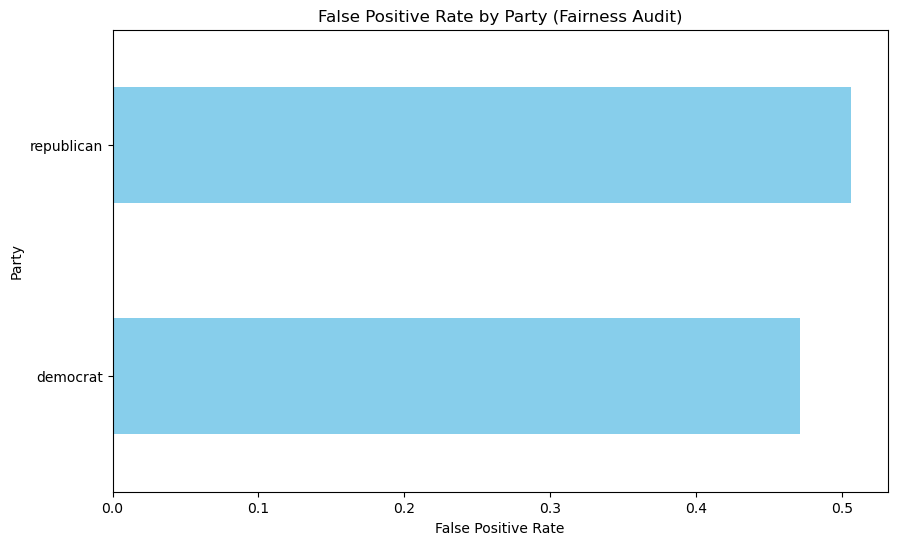

In [18]:
import matplotlib.pyplot as plt

# Plotting False Positive Rate by Group
mf_political.by_group['false_positive_rate'].sort_values().plot(
    kind='barh', 
    figsize=(10, 6), 
    color='skyblue',
    title='False Positive Rate by Party (Fairness Audit)'
)
plt.xlabel('False Positive Rate')
plt.ylabel('Party')
plt.show()

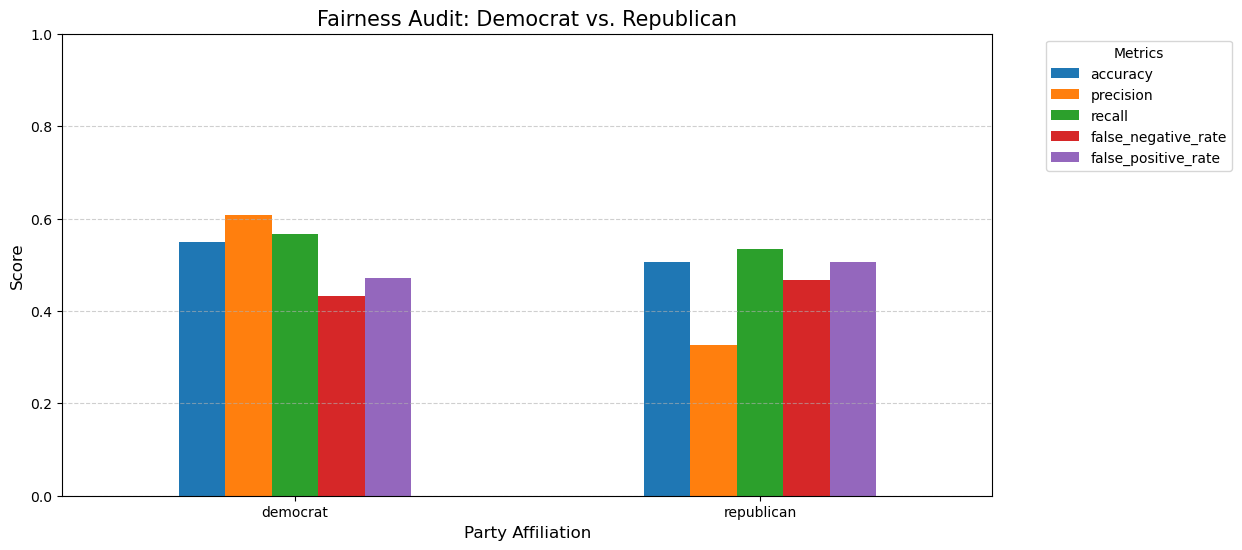

In [19]:
import matplotlib.pyplot as plt

# Plot all metrics side-by-side
ax = mf_political.by_group.plot(
    kind='bar', 
    figsize=(12, 6), 
    rot=0,
    ylim=(0, 1) # Metrics are between 0 and 1
)

plt.title("Fairness Audit: Democrat vs. Republican", fontsize=15)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Party Affiliation", fontsize=12)
plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

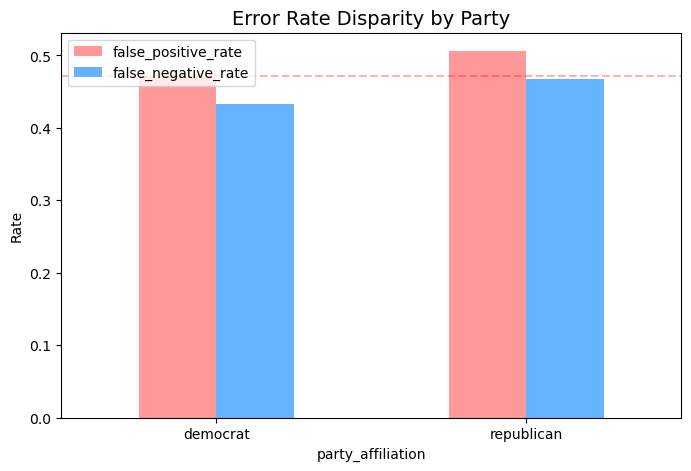

In [20]:
# Focus specifically on error rates
error_metrics = mf_political.by_group[['false_positive_rate', 'false_negative_rate']]

error_metrics.plot(
    kind='bar', 
    color=['#ff9999','#66b3ff'], 
    figsize=(8, 5),
    rot=0
)

plt.title("Error Rate Disparity by Party", fontsize=14)
plt.ylabel("Rate")
plt.axhline(y=error_metrics.loc['democrat', 'false_positive_rate'], color='red', linestyle='--', alpha=0.3)
plt.show()

  0%|          | 0/498 [00:00<?, ?it/s]

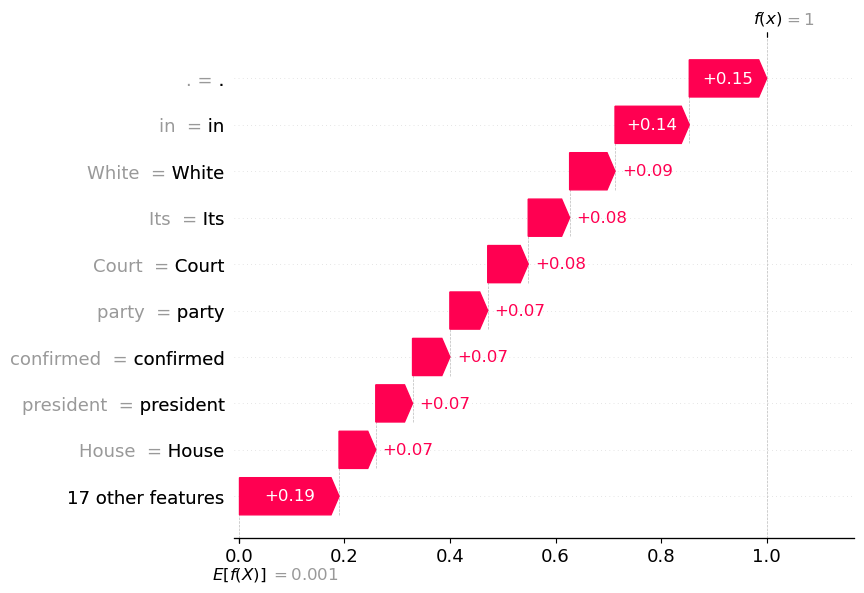

In [42]:
import shap
from transformers import pipeline


model.to("cpu")
model.eval()

# 2. Define a SHAP-specific prediction function
# SHAP sends a list of strings; this function must return a numpy array of probabilities
def predict_shap(texts):
    inputs = tokenizer(list(texts), padding=True, truncation=True, return_tensors="pt").to("cpu")
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    return probs.detach().numpy()

# 3. Initialize the Explainer
explainer = shap.Explainer(predict_shap, masker=shap.maskers.Text(tokenizer), output_names=['Fake', 'Real'])

# 4. Identify Republican mistakes (where the model was wrong)
# Using 'clear_news_to_test' as per your dataset variable
republican_mistakes = clear_news_to_test[
    (clear_news_to_test['party_affiliation'] == 'republican') & 
    (clear_news_to_test['true_label'] != clear_news_to_test['pred_label'])
].copy()

# 5. FIX: Correctly format the text input
# We extract the statement as a string and wrap it in a list
test_statement = [str(republican_mistakes['statement'].iloc[4])]

# 6. Run the explanation
shap_values = explainer(test_statement)

# 7. Visualize
# This shows which words pushed the model toward the 'Real' prediction
shap.plots.waterfall(shap_values[0, :, "Real"])